# Analysis


## Load Preprocessed Data


The preprocessing pipeline is implemented in `scripts/build_analysis_dataset.py`. It creates `Data/analysis_dataset.csv` for EDA/modeling and `Data/palestine_voting_filtered.csv` for the voting visualizations.

To rebuild the files, run `python scripts/build_analysis_dataset.py` from the project root.

In [1]:
from pathlib import Path
import os

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, precision_score, roc_auc_score, roc_curve, auc

DATA_DIR = Path("Data")
df_speech = pd.read_csv(DATA_DIR / "analysis_dataset.csv")
palestine_voting = pd.read_csv(DATA_DIR / "palestine_voting_filtered.csv", parse_dates=["date"])

In [2]:
df_speech.head()

,id,Session,Year,ms_code,Country or Area,Region Name,palestine_sentences_count,palestine_keywords_count,Speech_Compound,Sentiment,total_votes,yes_votes,yes_pcg,recognition_year,recognized_palestine
0,0,1,1946,ARG,Argentina,Americas,0,0,NaN,NEUTRAL,NaN,NaN,NaN,2010.0,False
1,1,1,1946,AUS,Australia,Oceania,1,1,0.340000,POSITIVE,NaN,NaN,NaN,NaN,False
2,2,1,1946,BEL,Belgium,Europe,2,2,0.694400,POSITIVE,NaN,NaN,NaN,NaN,False
3,3,1,1946,BLR,Belarus,Europe,4,4,-0.156675,NEGATIVE,NaN,NaN,NaN,1988.0,False
4,4,1,1946,BOL,Bolivia (Plurinational State of),Americas,1,1,0.912800,POSITIVE,NaN,NaN,NaN,2010.0,False


### Starting EDA analysis

In [23]:
os.makedirs("figs", exist_ok=True)

From 1946 up to 1968, resolutions only from 3 years were recorded, so we exclude them from our dataset and focus from 1969 to 2024.

#### Use of Palestine mentions and Sentiment per year

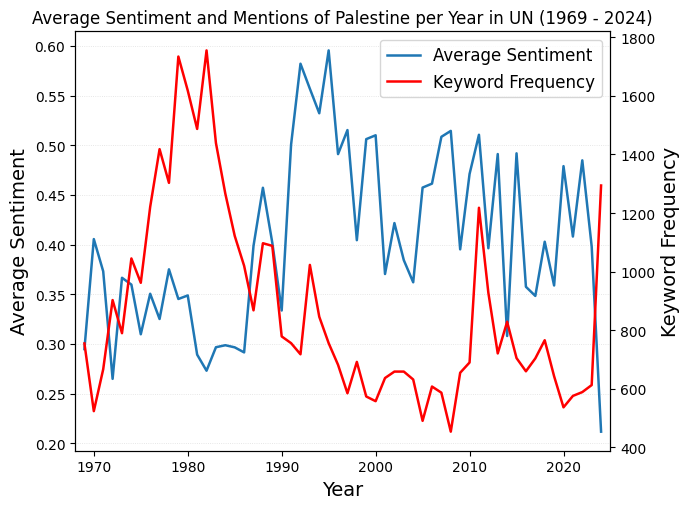

In [24]:
freq_per_year = df_speech[df_speech['Year'] >= 1969]

sentiment_per_year = (
    freq_per_year.groupby('Year', as_index=False)['Speech_Compound']
    .mean()
    .sort_values('Year')
)

keywords_per_year = (
    freq_per_year.groupby('Year', as_index=False)['palestine_keywords_count']
    .sum()
    .sort_values('Year')
)

fig, ax1 = plt.subplots(figsize=(7.0, 5.2))

ax1.plot(
    sentiment_per_year['Year'], sentiment_per_year['Speech_Compound'],
    color="tab:blue", linewidth=1.8, label="Average Sentiment"
)
ax1.set_xlabel("Year", fontsize=14)
ax1.set_ylabel("Average Sentiment", fontsize=14)
ax1.tick_params(axis='y')
ax1.grid(axis='y', linestyle=':', linewidth=0.6, alpha=0.4)

ax2 = ax1.twinx()
ax2.plot(keywords_per_year['Year'], keywords_per_year['palestine_keywords_count'],color="red", linewidth=1.8, label="Keyword Frequency")
ax2.set_ylabel("Keyword Frequency", fontsize=14)
ax2.tick_params(axis='y')

ax1.set_xlim(min(sentiment_per_year['Year'].min(), keywords_per_year['Year'].min()) - 1,
    max(sentiment_per_year['Year'].max(), keywords_per_year['Year'].max()) + 1
)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right", fontsize=12)


plt.title("Average Sentiment and Mentions of Palestine per Year in UN (1969 - 2024)")

fig.tight_layout()


fig.savefig("figs/palestine_sentiment_and_keywords.png", dpi=600, bbox_inches="tight", facecolor="white")
# fig.savefig("figs/palestine_sentiment_and_keywords.eps")

plt.show()


# Mentions per Region

In [25]:
# country_freq: ['ISO-alpha3 Code','Country or Area','Mentions']
country_freq = df_speech[df_speech['Year'] >= 1969]
country_freq = country_freq.groupby('ms_code')['palestine_keywords_count'].sum().reset_index().rename(columns={'ms_code':'ISO-alpha3 Code'})

fig = px.choropleth(
    country_freq,
    locations='ISO-alpha3 Code',
    color='palestine_keywords_count',
    hover_data=None,                     # no tooltips
    color_continuous_scale='YlOrRd',      # neutral, paper-friendly
    range_color=(0, country_freq['palestine_keywords_count'].max()),
    locationmode='ISO-3'   
)

fig.update_geos(
    projection_type='natural earth',
    showcoastlines=True, coastlinecolor='#9e9e9e',
    showcountries=True,  countrycolor='#bdbdbd',
    showland=True,        landcolor='#f7f7f7',
    showocean=True,       oceancolor='white',
    showframe=True,       framecolor='#9e9e9e'
)

fig.update_layout(
    template='simple_white',
    title=dict(
        text="Use of Palestine in UN General Debate Speeches (1969 - 2024)",
        font=dict(family="Times New Roman", size=18, color="black"),
        x=0.5,       # center
        xanchor="center",
        y=0.95,      # move slightly down from the top edge
        yanchor="top"
    ),
    margin=dict(l=10, r=10, t=60, b=10),  # extra top margin for title
    coloraxis_colorbar=dict(
        title='Mentions',
        tickformat=',d',
        thickness=12, len=0.75
    ),
    hovermode=False,
    font=dict(family='Times New Roman', size=14)
)

fig.show()
fig.write_image("figs/choropleth_palestine_mentions.png", width=1400, height=800, scale=3)

### Voting behavior per country

We will create a world map that shows the percentage of yes in Palestine resolutions from 1969 to 2024.

In [26]:
active_countries = palestine_voting.loc[(palestine_voting["Year"] >= 2020) & (palestine_voting["Year"] <= 2026), "ms_code"].unique()

# keep all history for only those countries
palestine_voting['year_max'] = palestine_voting.groupby('ms_name')['Year'].transform('max')
df_filtered = palestine_voting[palestine_voting["ms_code"].isin(active_countries)].reset_index()

df_filtered.sort_values('year_max')

vote_map = {"Y": "yes", "N": "no", "A": "abstention", "X": "non_voting"}

for code, col in vote_map.items():
    df_filtered[col] = (df_filtered["ms_vote"] == code).astype(int)

agg_df = df_filtered.groupby(["ms_code", "ms_name","year_max"])[["yes", "no", "abstention", "non_voting"]].sum()

# aggregate by country
agg_df_yearly = df_filtered.groupby(["ms_code", "ms_name","year_max","Year"])[["yes", "no", "abstention", "non_voting"]].sum()

# compute totals and percentage of YES
agg_df["total_votes"] = agg_df.sum(axis=1)
agg_df["pct_yes"] = agg_df["yes"] / agg_df["total_votes"]
agg_df.sort_values('year_max', ascending=False, inplace=True)
agg_df.reset_index(inplace=True)

# compute totals and percentage of YES
agg_df_yearly["total_votes"] = agg_df_yearly.sum(axis=1)
agg_df_yearly["pct_yes"] = agg_df_yearly["yes"] / agg_df_yearly["total_votes"]
agg_df_yearly.sort_values('year_max', ascending=False, inplace=True)
agg_df_yearly.reset_index(inplace=True)

# select all rows where ms_code is duplicated
x = agg_df.reset_index()
duplicates = x[x.duplicated(subset='ms_code', keep=False)].reset_index().sort_values(by=['ms_code', 'year_max'], ascending=[True, False])

In [27]:
latest_names = agg_df_yearly.loc[agg_df_yearly.groupby('ms_code')['year_max'].idxmax(), ['ms_code','ms_name']]

# create a mapping dictionary
name_map = dict(zip(latest_names['ms_code'], latest_names['ms_name']))

# update ms_name for all rows using the mapping
agg_df_yearly['ms_name'] = agg_df_yearly['ms_code'].map(name_map)

# we track only from 1969 to 2024
agg_df_yearly = agg_df_yearly[agg_df_yearly['Year'] >= 1969]

In [28]:
max_year = agg_df.groupby('ms_code')['year_max'].transform('max')

# keep only rows where year_max equals the max for that country
latest_rows = agg_df.loc[agg_df['year_max'] == max_year, ['ms_code', 'ms_name', 'year_max']]

# sum totals per country
totals = agg_df.groupby('ms_code')[['yes','no','abstention','non_voting','total_votes']].sum().reset_index()

# merge summed totals with latest row info
df_final = latest_rows.merge(totals, on='ms_code')

df_final['pct_yes'] = round(df_final['yes'] / df_final['total_votes'] ,4)*100

In [29]:
max_year = agg_df.groupby('ms_code')['year_max'].transform('max')
latest_rows = agg_df.loc[agg_df['year_max'] == max_year, ['ms_code', 'ms_name', 'year_max']]
totals = agg_df.groupby('ms_code')[['yes','no','abstention','non_voting','total_votes']].sum().reset_index()
df_final = latest_rows.merge(totals, on='ms_code')
df_final['pct_yes'] = round(df_final['yes'] / df_final['total_votes'] ,4)*100

df = df_final.reset_index()  

fig = px.choropleth(
    df,
    locations="ms_code",
    color="pct_yes",
    hover_name="ms_name",
    color_continuous_scale="OrRd",
    projection="natural earth",
    title="Precentage of voting Yes on Palestine resolutions",
)

fig.update_geos(
    projection_type='natural earth',
    showcoastlines=True, coastlinecolor='#9e9e9e',
    showcountries=True,  countrycolor='#bdbdbd',
    showland=True,        landcolor='#f7f7f7',
    showocean=True,       oceancolor='white',
    showframe=True,       framecolor='#9e9e9e'
)

fig.update_layout(
    template='simple_white',
    title=dict(
        text="",
        font=dict(family="Times New Roman", size=18, color="black"),
        x=0.5,       # center
        xanchor="center",
        y=0.95,      # move slightly down from the top edge
        yanchor="top"
    ),
    margin=dict(l=10, r=10, t=60, b=10),  # extra top margin for title
    coloraxis_colorbar=dict(
        title='Yes percentage',
        tickformat=',d',
        thickness=12, len=0.95
    ),
    hovermode=False,
    font=dict(family='Times New Roman', size=14)
)
fig.show()
fig.write_image("figs/choropleth_palestine_voting.png", width=1400, height=800, scale=3)

### Voting behavior and Palestine recognition

In [30]:
palestine_voting.shape

(133609, 16)

In [31]:
votings_speeches = palestine_voting.merge(df_speech[['ms_code', 'Year', 'recognized_palestine']], on=['ms_code', 'Year'])

In [32]:
votings_speeches.shape  # there are some years where some countries did not have a speech in United Nations

(128041, 17)

In [33]:
# first countries that recognize Palestine
votings_speeches = votings_speeches[votings_speeches['Year'] >= 1988]
votings_speeches['vote_category'] = votings_speeches['ms_vote'].apply(lambda x: 'Yes' if x == 'Y' else 'Other')

In [34]:
votings_speeches['is_yes'] = votings_speeches['ms_vote'].apply(lambda x: 1 if x == 'Y' else 0)
yes_summary = votings_speeches.groupby(['Year','recognized_palestine']).agg(total_votes=('ms_vote', 'count'),yes_votes=('is_yes', 'sum')).reset_index()
yes_summary['yes_percentage'] = yes_summary['yes_votes'] / yes_summary['total_votes'] * 100
yes_summary.head()

,Year,recognized_palestine,total_votes,yes_votes,yes_percentage
0,1988,False,1008,700,69.444444
1,1988,True,1064,1030,96.804511
2,1989,False,990,759,76.666667
3,1989,True,1215,1149,94.567901
4,1990,False,1380,1033,74.855072


In [35]:
yes_summary['recognized_palestine'] = yes_summary['recognized_palestine'].replace(True,'Yes')
yes_summary['recognized_palestine'] = yes_summary['recognized_palestine'].replace(False,'No')

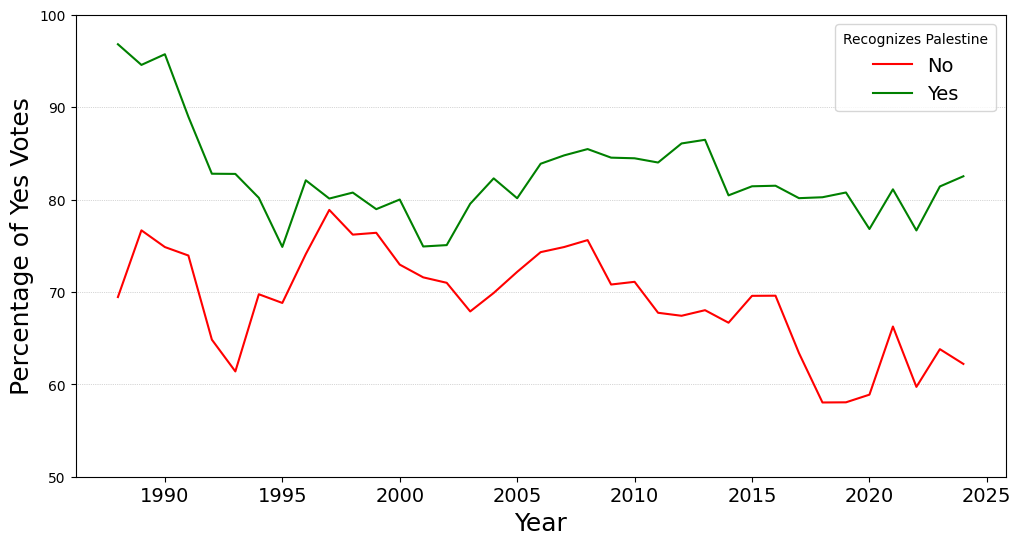

In [36]:
plt.figure(figsize=(12,6))

sns.lineplot(data=yes_summary, x='Year', y='yes_percentage', hue='recognized_palestine', palette={'Yes': 'green', 'No': 'red'})

#plt.title("Percentage of 'Yes' Votes on Palestine by Recognition Status (1988 - 2024)")
plt.ylabel("Percentage of Yes Votes", fontsize=18)
plt.xlabel("Year", fontsize=18)
plt.legend(title="Recognizes Palestine", fontsize=14)
plt.ylim(50, 100)
plt.grid(axis='y', linestyle=':', linewidth=0.5, alpha=1)
plt.xticks(fontsize=14, rotation=0)
plt.savefig("figs/palestine_recognition.png", dpi=600, bbox_inches="tight", facecolor="white")
#plt.savefig("figs/palestine_recognition.eps")
plt.show()

# Number of mentions & Voting & Recognition of Palestine

In [37]:
yes_voters_speeches = df_speech[df_speech['yes_pcg'] > 0.5]
not_yes_voters_speeches = df_speech[df_speech['yes_pcg'] <= 0.5]

not_yes_copy = not_yes_voters_speeches.copy()
yes_copy = yes_voters_speeches.copy()

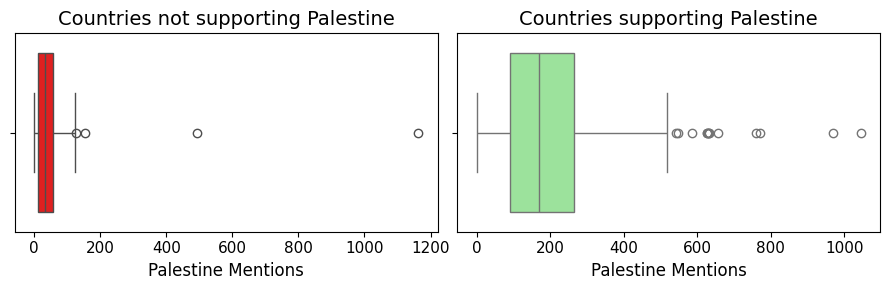

In [38]:
counts_not_yes = not_yes_copy.groupby('ms_code')['palestine_keywords_count'].sum()
counts_yes = yes_voters_speeches.groupby('ms_code')['palestine_keywords_count'].sum()

fig, axes = plt.subplots(1, 2, figsize=(9,3), sharey=True)

sns.boxplot(x=counts_not_yes, color="red", ax=axes[0])
axes[0].set_xlabel("Palestine Mentions", fontsize=12)
axes[0].set_title("Countries not supporting Palestine", fontsize=14)
axes[0].tick_params(axis='x', labelsize=11)
axes[0].tick_params(axis='y', labelsize=11)

sns.boxplot(x=counts_yes, color="lightgreen", ax=axes[1])
axes[1].set_xlabel("Palestine Mentions", fontsize=12)
axes[1].set_title("Countries supporting Palestine", fontsize=14)
axes[1].tick_params(axis='x', labelsize=11)
axes[1].tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.savefig("figs/boxplot_mentions.png", dpi=600, bbox_inches="tight", facecolor="white")
#plt.savefig("figs/boxplot_mentions.eps")
plt.show()


In [39]:
counts_not_yes.sort_values(ascending=False).head(2)

ms_code
ISR    1163
USA     492
Name: palestine_keywords_count, dtype: int64

In [40]:
counts_yes.sort_values(ascending=False).head(2)

ms_code
JOR    1045
EGY     969
Name: palestine_keywords_count, dtype: int64

By observing the boxplots, we can exclude outliers of countries of Israel and USA from the countries that do not support Palestine, and also exclude Egypt and Jordan from the countries that do support in Palestine. Especially the first 2 countries differ significantly from the rest in terms of Palestine mentions.

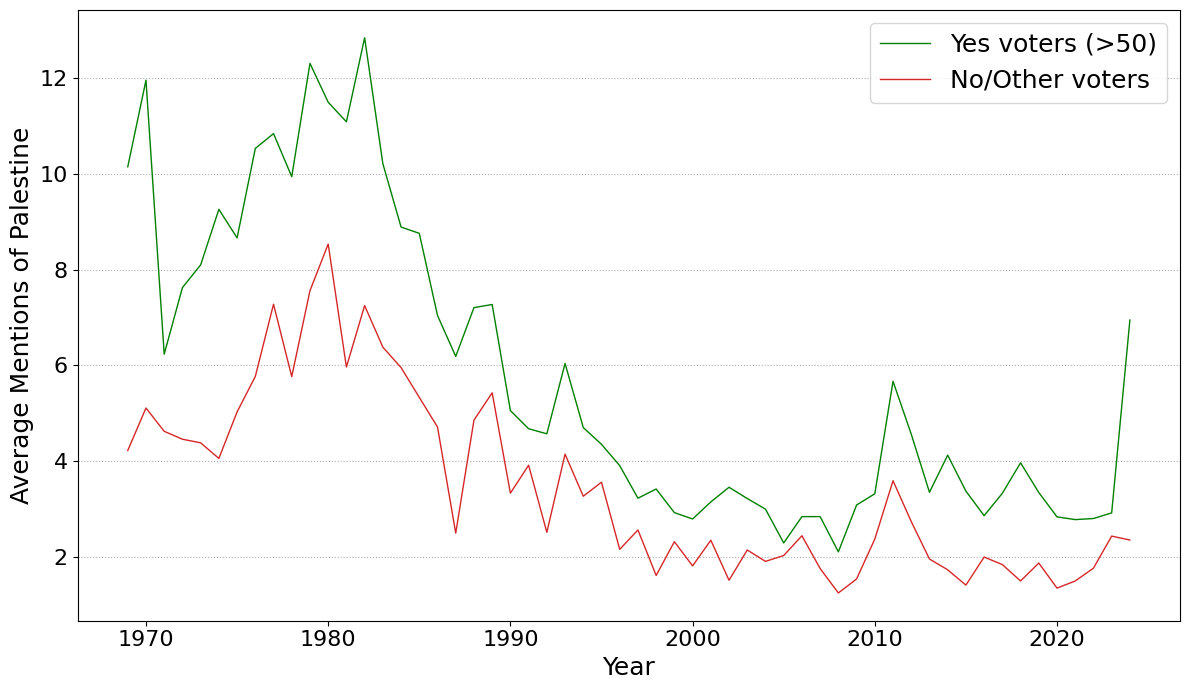

In [42]:
not_yes_voters_speeches = not_yes_voters_speeches[~not_yes_voters_speeches['ms_code'].isin(['ISR', 'USA'])]
yes_voters_speeches = yes_voters_speeches[~yes_voters_speeches['ms_code'].isin(['EGY', 'JOR'])]


not_yes_mentions = not_yes_voters_speeches.groupby("Year")["palestine_keywords_count"].mean().reset_index(name="mentions_not_yes")
yes_mentions = yes_voters_speeches.groupby("Year")["palestine_keywords_count"].mean().reset_index(name="mentions_yes")

all_mentions = yes_mentions.merge(not_yes_mentions, on="Year")
all_mentions = all_mentions[all_mentions['Year'] >= 1969]

plt.figure(figsize=(12, 7))

plt.plot(all_mentions["Year"], all_mentions["mentions_yes"], 
         label="Yes voters (>50)", linewidth=1, color="green")  # blue
plt.plot(all_mentions["Year"], all_mentions["mentions_not_yes"], 
         label="No/Other voters", linewidth=1, color="#d62728")  # red

plt.xlabel("Year", fontsize=18)
plt.ylabel("Average Mentions of Palestine", fontsize=18)
# plt.title("Mentions of Palestine in Speeches by Voting Behavior (>50%) (1969 - 2024)", fontsize=16)

plt.grid(axis='y', linestyle=':', linewidth=0.8, alpha=1)

plt.legend(title="", fontsize=18, title_fontsize=12)

plt.xticks(fontsize=16, rotation=0)
plt.yticks(fontsize=16)

plt.tight_layout()

plt.savefig("figs/palestine_mentions_voting.png", dpi=600, bbox_inches="tight", facecolor="white")
#plt.savefig("figs/palestine_mentions_voting.eps")
plt.show()

### Create model

We will train a model that uses: 
* number of palestine mentions
* the region of the country
* whether the country has recognized Palestine
* Sentiment (label Positive, Negative, Neutral)

In order to predict if that country voted in favor or against Palestine for the given resolution (0 for No, 1 for Yes). 

This is a classification problem, so we use a Random Forest Classifier for this purpose. 

In [22]:
def classify_yes(row):
    if row > 0.5:
        return 1
    else:
        return 0

# our Y variable
df_speech['voted_yes'] = df_speech['yes_pcg'].apply(classify_yes)

In [23]:
# drop speeches where on that year there were no resolutions related to Palestine
df = df_speech.dropna(subset='yes_pcg') 

In [24]:
dataset = df[['Year', 'ms_code', 'palestine_keywords_count', 'Region Name', 'Sentiment', 'recognized_palestine', 'voted_yes']]

In [25]:
# drop the outliers mentioned previously
dataset = dataset[~dataset['ms_code'].isin(['ISR', 'USA', 'EGY', 'JOR'])]

We observe that our predicting variable is highly imbalanced. For this reason, we will focus more on improving the f1 score for the countries that did not support Palestine, instead of focusing on accuracy.

In [26]:
# from 1946 up to 1968 there are only 3 years for which there was a resolution related to Palestine, so we exclude them
dataset = dataset[dataset['Year'] >= 1969]

In [27]:
dataset['voted_yes'].value_counts(normalize=True)

voted_yes
1    0.815187
0    0.184813
Name: proportion, dtype: float64

In [28]:
# this is the point where we can separate out training and test data in order to have 80% and 20% samples.
print(dataset[dataset['Year'] <= 2015].shape[0] / dataset.shape[0])

0.8121719709659408


In [29]:
X = dataset[['Year', 'palestine_keywords_count', 'Region Name', 'recognized_palestine', 'Sentiment']]
y = dataset['voted_yes']

# convert categorical variables to dummies
X = pd.get_dummies(X, columns=['Year', 'Region Name', 'recognized_palestine', 'Sentiment'])

# this is the point where we get 80% 20%
X_train = X[dataset['Year'] <= 2015]
y_train = y[dataset['Year'] <= 2015]

X_test = X[dataset['Year'] > 2015]
y_test = y[dataset['Year'] > 2015]

Compare models to find the one with the best results

In [30]:
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
nb_model = GaussianNB()
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

rf_model.fit(X_train, y_train)
nb_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_nb = nb_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
acc_nb = accuracy_score(y_test, y_pred_nb)
acc_lr = accuracy_score(y_test, y_pred_lr)

print("Random Forest Accuracy (2016-2024): \n", round(acc_rf,3))
print(classification_report(y_test, y_pred_rf))

print("Naive Bayes Accuracy (2016-2024): \n", round(acc_nb,3))
print(classification_report(y_test, y_pred_nb))

print("Logistic Regression Accuracy (2016-2024): \n", round(acc_lr,3))
print(classification_report(y_test, y_pred_lr))

Random Forest Accuracy (2016-2024): 
 0.837
              precision    recall  f1-score   support

           0       0.56      0.54      0.55       313
           1       0.90      0.90      0.90      1369

    accuracy                           0.84      1682
   macro avg       0.73      0.72      0.73      1682
weighted avg       0.83      0.84      0.84      1682

Naive Bayes Accuracy (2016-2024): 
 0.844
              precision    recall  f1-score   support

           0       0.66      0.33      0.44       313
           1       0.86      0.96      0.91      1369

    accuracy                           0.84      1682
   macro avg       0.76      0.65      0.68      1682
weighted avg       0.82      0.84      0.82      1682

Logistic Regression Accuracy (2016-2024): 
 0.518
              precision    recall  f1-score   support

           0       0.27      0.96      0.42       313
           1       0.98      0.42      0.59      1369

    accuracy                           0.52   

Although Gaussian Naive Bayes yields better accuracy, we select Random Forest since we want to take into account the imbalance in our predictive variable. As a result, we will focus on f1-score, where Random Forest gives superior results.

### Grid search for Random Forest Classifier

Find the best hyperparameters of the Random Forest model

In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 50],
    'min_samples_split': [2, 5, 10]
}
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
grid_search = GridSearchCV(
    rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters: {'max_depth': 50, 'min_samples_split': 2, 'n_estimators': 300}
0.835909631391201
              precision    recall  f1-score   support

           0       0.57      0.51      0.54       313
           1       0.89      0.91      0.90      1369

    accuracy                           0.84      1682
   macro avg       0.73      0.71      0.72      1682
weighted avg       0.83      0.84      0.83      1682



### Apply with the best parameters

In [32]:
X = dataset[['Year', 'palestine_keywords_count', 'Region Name', 'recognized_palestine', 'Sentiment']]
y = dataset['voted_yes']

# convert categorical variables to dummies
X = pd.get_dummies(X, columns=['Year', 'Region Name', 'recognized_palestine', 'Sentiment'])

# this is the point where we get 80% 20%
X_train = X[dataset['Year'] <= 2015]
y_train = y[dataset['Year'] <= 2015]

X_test = X[dataset['Year'] > 2015]
y_test = y[dataset['Year'] > 2015]

model = RandomForestClassifier(random_state=42, class_weight='balanced', max_depth=50, min_samples_split=2, n_estimators=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy for years: 2016-2024", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy for years: 2016-2024 0.8353151010701546
              precision    recall  f1-score   support

           0       0.56      0.51      0.53       313
           1       0.89      0.91      0.90      1369

    accuracy                           0.84      1682
   macro avg       0.73      0.71      0.72      1682
weighted avg       0.83      0.84      0.83      1682



Accuracy is slightly decreased but f1-score (our target metric to improve) is increased.

### Find the most important features

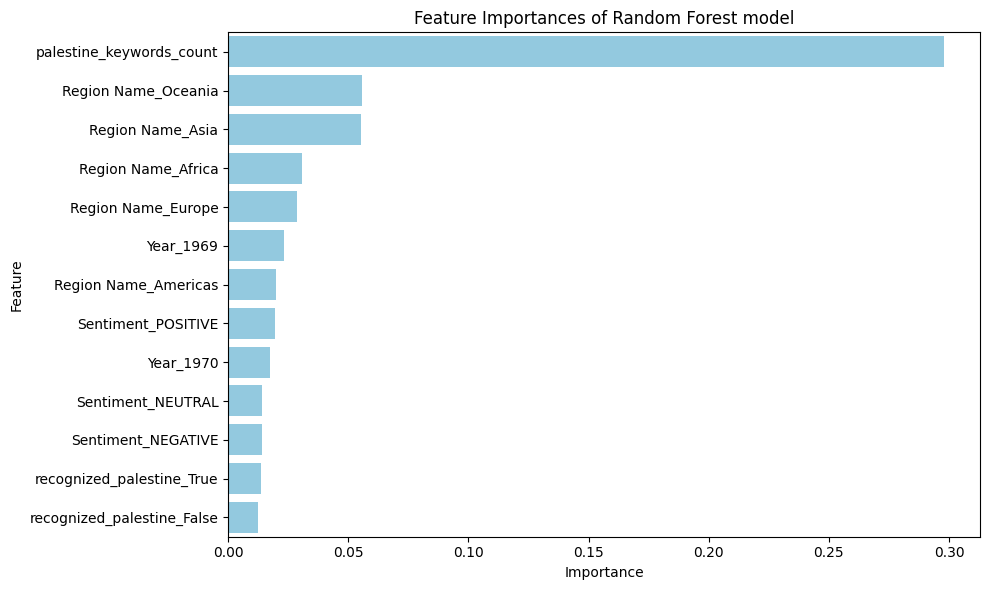

In [33]:
importances = model.feature_importances_
feature_names = X.columns

feat_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)


plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp_df.head(13),x="Importance", y="Feature",color="skyblue")
plt.title("Feature Importances of Random Forest model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
#plt.savefig("figs/feature_importance.png", dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig("figs/feature_importance.eps")
plt.show()

We observe from the feature importance of the model that speech activity about Palestine is the strongest predictor, with regional and temporal context adding some information, while sentiment and formal recognition play a very minor role.

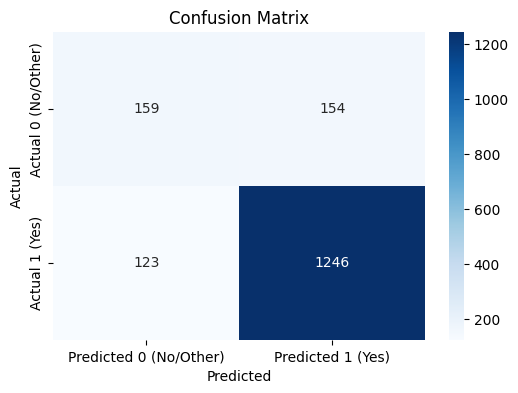

In [34]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted 0 (No/Other)", "Predicted 1 (Yes)"],
            yticklabels=["Actual 0 (No/Other)", "Actual 1 (Yes)"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
#plt.savefig("figs/confusion_matrix.png", dpi=600, bbox_inches="tight", facecolor="white")
plt.savefig("figs/confusion_matrix.eps")
plt.show()

In [35]:
y_train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)

y_test_pred = model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train Accuracy (up to 2015): {train_acc:.3f}")
print(f"Test Accuracy (2016-2024): {test_acc:.3f}\n")

print("Classification Report (Test set):")
print(classification_report(y_test, y_test_pred))

Train Accuracy (up to 2015): 0.882
Test Accuracy (2016-2024): 0.835

Classification Report (Test set):
              precision    recall  f1-score   support

           0       0.56      0.51      0.53       313
           1       0.89      0.91      0.90      1369

    accuracy                           0.84      1682
   macro avg       0.73      0.71      0.72      1682
weighted avg       0.83      0.84      0.83      1682



the difference between training and test is not so significant

In [36]:
X_test = X[dataset['Year'] ==  2024]
y_test = y[dataset['Year'] == 2024]

y_pred = model.predict(X_test)

print("Accuracy for year: 2024", round(accuracy_score(y_test, y_pred), 3))
print(classification_report(y_test, y_pred))

Accuracy for year: 2024 0.838
              precision    recall  f1-score   support

           0       0.52      0.42      0.46        31
           1       0.89      0.92      0.90       154

    accuracy                           0.84       185
   macro avg       0.70      0.67      0.68       185
weighted avg       0.83      0.84      0.83       185



In [ ]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

tpr = recall_score(y_test, y_pred, pos_label=1)  # Sensitivity
tnr = tn / (tn + fp)                             # Specificity
precision = precision_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"TPR (Recall/Sensitivity): {tpr:.3f}")
print(f"TNR (Specificity): {tnr:.3f}")
print(f"Precision: {precision:.3f}")
print(f"AUC: {auc:.3f}")

In [46]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # For AUC

print("Accuracy (2016-2024):", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

tpr = recall_score(y_test, y_pred, pos_label=1)  # sensitivity
tnr = tn / (tn + fp)  # specificity
precision = precision_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_proba)

print(f"TPR (Recall/Sensitivity): {tpr:.3f}")
print(f"TNR (Specificity): {tnr:.3f}")
print(f"Precision: {precision:.3f}")
print(f"AUC: {auc_score:.3f}")


Accuracy (2016-2024): 0.8378378378378378

Classification Report:
               precision    recall  f1-score   support

           0       0.52      0.42      0.46        31
           1       0.89      0.92      0.90       154

    accuracy                           0.84       185
   macro avg       0.70      0.67      0.68       185
weighted avg       0.83      0.84      0.83       185

TPR (Recall/Sensitivity): 0.922
TNR (Specificity): 0.419
Precision: 0.887
AUC: 0.806


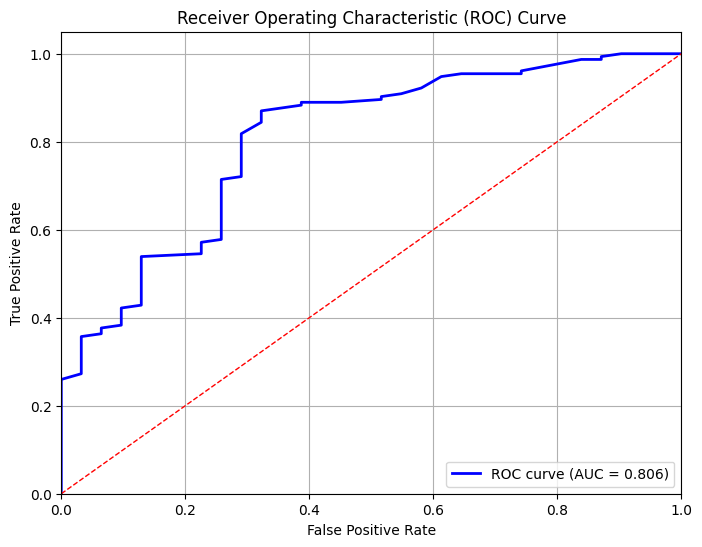

In [48]:
fpr, tpr_curve, thresholds = roc_curve(y_test, y_proba)  # binary classification
roc_auc = auc(fpr, tpr_curve)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr_curve, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--')  # diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()